## 异常检测

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import load_iris
%matplotlib inline

### outline
- 简介
- 数学推导
- 特征选择
- 优缺点
- sklearn实战

### 简介
异常检测通常属于无监督学习（严格来说它存在半监督检测和有监督检测），它的目标不是寻找数据中的类别，而是判断一个样本是否偏离正常数据的分布。它与聚类、降维的目标不同，聚类关注数据可以划分成哪些群体，降维关注如何用更少的维度表示数据，而异常检测关注的是哪些样本与正常数据存在明显差异。异常检测既可以用于发现数据中的异常样本，也可以作为机器学习模型的数据预处理步骤，在确认异常样本属于数据噪声或错误记录后将其剔除。

### 数学推导
它背后的原理主要是正态分布，高斯函数用于描述正态分布
$$f_{(\sigma,\mu)}(x)=\frac{1}{\sqrt{2 \pi }\sigma}  \exp (\frac{-1}{2}(\frac{x-\mu}{\sigma})^2)$$
- $\mu$ 期望
- $\sigma$ 标准差
- x为随机变量
- f_{(\sigma,\mu)}(x) 连续性随机变量为X在x处的概率密度

正态分布它源于对测量误差的研究，它描述的是一个随机变量在大量独立微小的随机因素共同作用下形成的概率分布。在正态分布中，越接近均值的区域概率密度越高，随着距离均值越来越远，概率密度逐渐降低，因此距离均值较远的样本出现的概率相对较低。下面均值为0，方差为1的正态分布图像为一个钟形，可以发现在均值附近点的概率最高，然后远离均值的点越来越低。（背后由中心极限定理作为支撑）

> 当一个随机变量受到大量相互独立、影响较小的随机因素共同作用时，在满足一定条件的情况下，这些随机因素的总和经过标准化后会趋近于正态分布，这就是中心极限定理。

我们的数据样本中不可能只有一个特征这么简单可能有多个构成，当然对应高斯函数也可以是多维特征构成(概率论中联合分布)，比如下面二元高斯函数是一个3d钟形，数据大多数也是平均值附近）
$$N(\sigma_x,\mu_x,\sigma_y,\mu_y)=\frac{1}{\sqrt{2 \pi }\sigma_x}  \exp (\frac{-1}{2}(\frac{x-\mu_x}{\sigma_x})^2) \frac{1}{\sqrt{2 \pi }\sigma_y}  \exp (\frac{-1}{2}(\frac{y-\mu_y}{\sigma_y})^2)$$
> 如果采用各个特征概率密度直接相乘的简化方法，则假设特征之间相互独立；如果使用完整的多元高斯分布，则可以通过协方差矩阵描述特征之间的相关性，并不要求特征相互独立。

这个算法通过$\epsilon$来划分正常/异常的阈值，对于样本x计算它在正态分布下的p(x),当$p(x)<\epsilon$时时异常样本，反之。

实际中通常使用带标签的验证集选择阈值 $(\epsilon)$。可以尝试不同的阈值，并根据 Precision、Recall、F1 等指标选择合适的阈值。同时可以使用 ROC-AUC、PR-AUC 对模型整体的异常识别能力进行评价。当异常样本比例很低时，PR-AUC 通常更加具有参考价值。

// todo 评估解释

### 特征选择与特征工程
- 特征选择 
单变量分布可以通过观察每个特征的直方图，判断是否适用高斯分布建模
    - 接近单峰
    - 严重偏斜
    - 存在长尾
    - 存在多个峰值
    - 有大量极端值
特征的分布越接近 Gaussian 建模的假设，使用 Gaussian 模型估计正常数据分布通常越合理；如果存在严重偏斜、长尾或明显多峰现象，则需要考虑特征变换或其他异常检测方法。

- 多特征之间相关性
对于多维数据，异常有时并不是某一个特征的值特别极端，而是多个特征组合起来比较异常。因此可以通过散点图、相关系数矩阵等方法观察特征之间的关系。

如果采用假设各特征相互独立的简化 Gaussian 模型，那么高度相关的特征会使这一假设不再合理。此时可以考虑删除高度冗余的特征，或者使用能够通过协方差矩阵描述特征相关性的多元 Gaussian 方法。
> 协方差矩阵，皮尔特系数查看关联的比较高的特征


- 特征工程
单变量特征不满足情况，根据数据分布，可以通过对数、平方根等变换减弱偏态，使特征分布更加适合模型。例如对于右偏且数据为正，可以尝试 $(x'=\log(x))$ 。log会压缩大数值，保留小数值之间差异比如X=[1,10,100,1000],log(x)=[0,1,2,3],改善分布形状



注意事项，在特征选择不要明显泄漏的信息放进去，比如计算整个数据集的$\mu \sigma$在划分数据



### 优缺点
- 优点
1. 该算法高效简单，易于实践
2. 计算效率高， 可解释性强通过概率密度来解释，p(x)低表示在正常数据中比较罕见
3. 适合明确统计分布的数据（比如某些传感器误差或者误差测量）

- 缺点
1. 对分布假设敏感，如果分布不满足特征选择要点，就会比较差
2. 对特征工程敏感，如果特征选择或者特征变换不合理，那么估计出的正常数据分布可能不准确，最终影响异常分数。
3. 特征之间关系敏感，数学上特征必须满足相互独立，如果特征之间存在明显关系，模型性能也会变低（可以修正）
4. 低概率不一定异常，可能是罕见而不是错误样本，还需具体结合业务

### sklearn实战
EllipticEnvelope 
- contamination 样本异常大约占比

decision_function给出异常评分，分数越低通常表示越异常；通过设定阈值，可以进一步将样本划分为正常样本和异常样本。


// todo其他异常检测


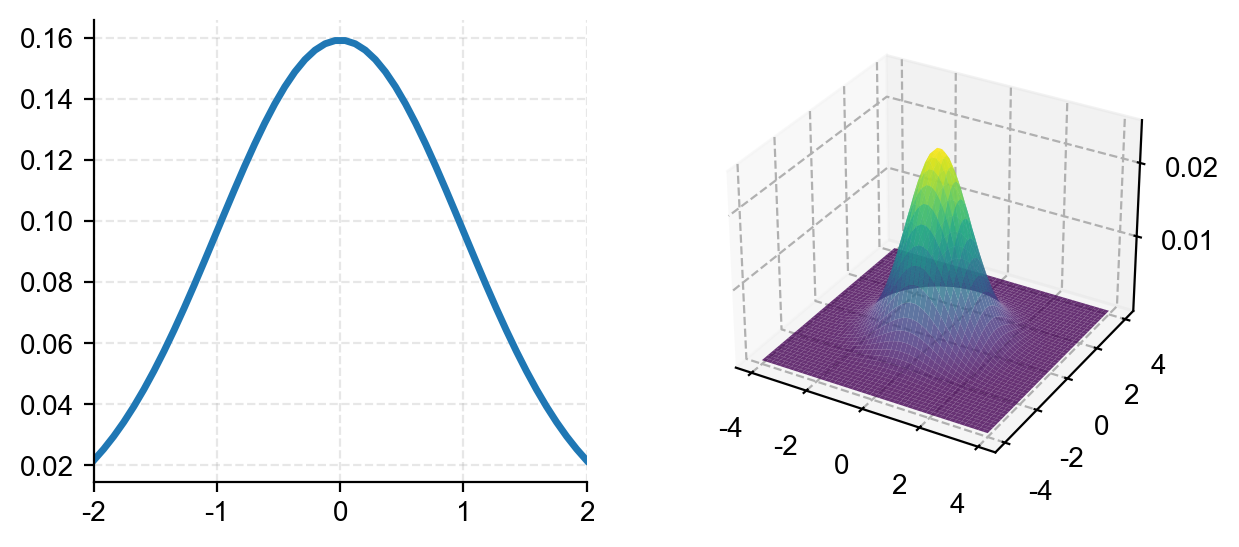

In [34]:
x=np.linspace(-2,2)
y=1/(2*np.pi)*np.exp(-1/2*(x)**2)

fig = plt.figure(figsize=(7,3))
ax1=fig.add_subplot(1,2,1)
ax1.plot(x,y)
ax1.set_xlim(-2,2)


x=np.linspace(-4,4)
xx,yy=np.meshgrid(x,x)
zz=1/(2*np.pi)*np.exp(-1/2*(yy)**2)*1/(2*np.pi)*np.exp(-1/2*(xx)**2)

ax2=fig.add_subplot(1,2,2,projection='3d')
ax2.plot_surface(xx,yy,zz,alpha=0.8,cmap='viridis')

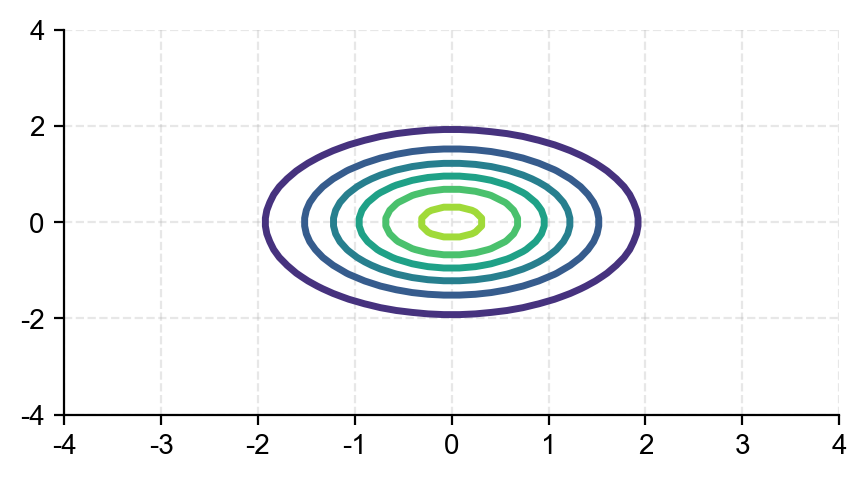